<a href="https://colab.research.google.com/github/abhinavmarkanda/UCS547-Accelerated-Data-Science/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python matplotlib torch torchvision

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [ ]:
import cv2
import numpy as np
import time
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import os

In [ ]:
def cpu_pipeline(image_paths):
    start_time = time.time()

    for path in image_paths:
        img = cv2.imread(path)
        img = cv2.resize(img, (512, 512))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    end_time = time.time()

    total_time = end_time - start_time
    avg_time = total_time / len(image_paths)

    return total_time, avg_time

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

def gpu_pipeline(image_paths):
    start_time = time.time()

    for path in image_paths:
        img = Image.open(path).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)

    torch.cuda.synchronize()  # wait for GPU

    end_time = time.time()

    total_time = end_time - start_time
    avg_time = total_time / len(image_paths)

    return total_time, avg_time

In [ ]:
image_paths = list(uploaded.keys())

print("Total images:", len(image_paths))

Total images: 1


In [ ]:
import zipfile
import os

zip_file_path = list(uploaded.keys())[0]
extraction_dir = 'extracted_images'

# Create the directory if it doesn't exist
os.makedirs(extraction_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f"Contents of '{zip_file_path}' extracted to '{extraction_dir}'")

Contents of 'archive (5).zip' extracted to 'extracted_images'


In [ ]:
image_paths = []
for root, _, files in os.walk(extraction_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))
print("First 5 image paths:", image_paths[:5])

Total images found: 38
First 5 image paths: ['extracted_images/data/landscape1.jpg', 'extracted_images/data/sky1.jpg', 'extracted_images/data/market1.jpg', 'extracted_images/data/people2.jpg', 'extracted_images/data/car2.jpg']


In [ ]:
cpu_total, cpu_avg = cpu_pipeline(image_paths)
gpu_total, gpu_avg = gpu_pipeline(image_paths)

speedup = cpu_total / gpu_total

print("CPU Total Time:", cpu_total)
print("CPU Avg Time:", cpu_avg)

print("GPU Total Time:", gpu_total)
print("GPU Avg Time:", gpu_avg)

print("Speedup:", speedup)

CPU Total Time: 3.6623177528381348
CPU Avg Time: 0.0963767829694246
GPU Total Time: 6.435779571533203
GPU Avg Time: 0.16936262030350535
Speedup: 0.5690558093439575


In [ ]:
import pandas as pd

data = {
    "Pipeline": ["CPU", "GPU"],
    "Total Time (s)": [cpu_total, gpu_total],
    "Avg Time/Image (s)": [cpu_avg, gpu_avg]
}

df = pd.DataFrame(data)
print(df)

  Pipeline  Total Time (s)  Avg Time/Image (s)
0      CPU        3.662318            0.096377
1      GPU        6.435780            0.169363


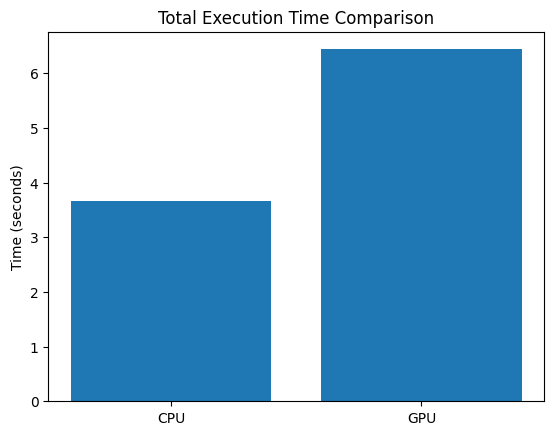

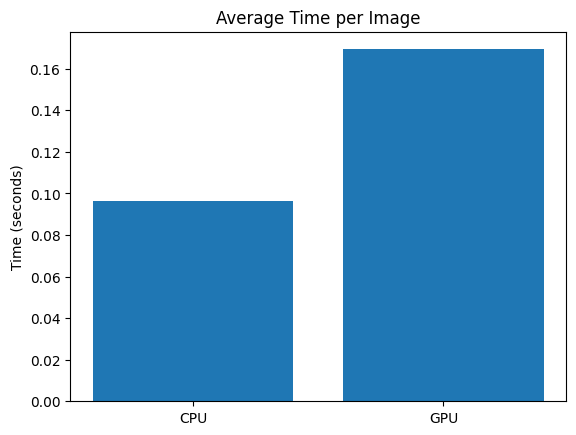

In [ ]:
# Total Time Graph
plt.figure()
plt.bar(["CPU", "GPU"], [cpu_total, gpu_total])
plt.title("Total Execution Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()

# Average Time Graph
plt.figure()
plt.bar(["CPU", "GPU"], [cpu_avg, gpu_avg])
plt.title("Average Time per Image")
plt.ylabel("Time (seconds)")
plt.show()

In [ ]:
%%writefile nvjpeg_gray.cu
#include <stdio.h>
#include <stdlib.h>
#include <nvjpeg.h>
#include <cuda_runtime.h>

#define CHECK_CUDA(call) { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error: %s\n", cudaGetErrorString(err)); \
        exit(1); \
    } \
}

#define CHECK_NVJPEG(call) { \
    nvjpegStatus_t status = call; \
    if (status != NVJPEG_STATUS_SUCCESS) { \
        printf("nvJPEG error: %d\n", status); \
        exit(1); \
    } \
}

// -------- Manual grayscale kernel --------
__global__ void rgb_to_gray(unsigned char* r, unsigned char* g, unsigned char* b,
                           unsigned char* gray, int size) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx < size) {
        gray[idx] = 0.299f * r[idx] + 0.587f * g[idx] + 0.114f * b[idx];
    }
}

// -------- Read file --------
unsigned char* read_file(const char* filename, size_t* size) {
    FILE* f = fopen(filename, "rb");
    fseek(f, 0, SEEK_END);
    *size = ftell(f);
    rewind(f);

    unsigned char* data = (unsigned char*)malloc(*size);
    fread(data, 1, *size, f);
    fclose(f);

    return data;
}

// -------- Save PGM (grayscale) --------
void save_pgm(const char* filename, unsigned char* data, int w, int h) {
    FILE* f = fopen(filename, "wb");
    fprintf(f, "P5\n%d %d\n255\n", w, h);
    fwrite(data, 1, w*h, f);
    fclose(f);
}

int main(int argc, char* argv[]) {

    if (argc < 2) {
        printf("Usage: ./a.out image.jpg\n");
        return 0;
    }

    const char* filename = argv[1];
    size_t file_size;
    unsigned char* jpeg_data = read_file(filename, &file_size);

    nvjpegHandle_t handle;
    nvjpegJpegState_t state;

    CHECK_NVJPEG(nvjpegCreateSimple(&handle));
    CHECK_NVJPEG(nvjpegJpegStateCreate(handle, &state));

    int widths[NVJPEG_MAX_COMPONENT];
int heights[NVJPEG_MAX_COMPONENT];

int channels;
nvjpegChromaSubsampling_t subsampling;

CHECK_NVJPEG(nvjpegGetImageInfo(handle, jpeg_data, file_size,
                                &channels, &subsampling,
                                widths, heights));

    int width = widths[0];
    int height = heights[0];
    int size = width * height;

    printf("Resolution: %dx%d\n", width, height);

    // -------- Allocate RGB --------
    nvjpegImage_t img_desc;
    unsigned char* d_channel[3];

    for (int i = 0; i < 3; i++) {
        CHECK_CUDA(cudaMalloc(&d_channel[i], size));
        img_desc.channel[i] = d_channel[i];
        img_desc.pitch[i] = width;
    }

    // -------- Decode to RGB --------
    CHECK_NVJPEG(nvjpegDecode(handle, state, jpeg_data, file_size,
                              NVJPEG_OUTPUT_RGB, &img_desc, 0));

    // -------- Manual grayscale --------
    unsigned char *d_gray_manual;
    CHECK_CUDA(cudaMalloc(&d_gray_manual, size));

    int threads = 256;
    int blocks = (size + threads - 1) / threads;

    rgb_to_gray<<<blocks, threads>>>(
        d_channel[0], d_channel[1], d_channel[2],
        d_gray_manual, size
    );

    CHECK_CUDA(cudaDeviceSynchronize());

    // -------- Copy result --------
    unsigned char* h_gray_manual = (unsigned char*)malloc(size);

    CHECK_CUDA(cudaMemcpy(h_gray_manual, d_gray_manual,
                          size, cudaMemcpyDeviceToHost));

    save_pgm("manual_gray.pgm", h_gray_manual, width, height);

    printf("Saved manual_gray.pgm\n");

    return 0;
}

Writing nvjpeg_gray.cu


In [ ]:
!nvcc nvjpeg_gray.cu -o nvjpeg_gray -lnvjpeg

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image.webp to image.webp


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image2.webp to image2.webp


In [ ]:
from PIL import Image

img = Image.open("image.webp").convert("RGB")
img.save("image1.jpg", "JPEG")

img = Image.open("image2.webp").convert("RGB")
img.save("image2.jpg", "JPEG")

In [ ]:
!./nvjpeg_gray image1.jpg
!./nvjpeg_gray image2.jpg

Resolution: 1080x1620
Saved manual_gray.pgm
Resolution: 1200x800
Saved manual_gray.pgm


(np.float64(-0.5), np.float64(1199.5), np.float64(799.5), np.float64(-0.5))

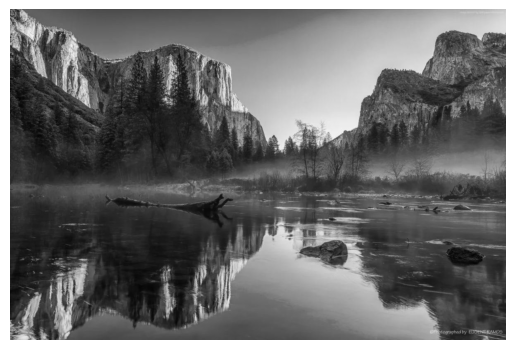

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("manual_gray.pgm")
plt.imshow(img, cmap='gray')
plt.axis('off')

In [1]:
!pip install opencv-python-headless torch torchvision nvidia-dali-cuda120 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.3/418.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 92.7 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [6]:
!unzip archive.zip

Archive:  archive.zip
  inflating: data/bird1.jpg          
  inflating: data/bird2.jpg          
  inflating: data/buildings1.jpg     
  inflating: data/buildings2.jpg     
  inflating: data/buildings3.jpg     
  inflating: data/car1.jpg           
  inflating: data/car2.jpg           
  inflating: data/data/bird1.jpg     
  inflating: data/data/bird2.jpg     
  inflating: data/data/buildings1.jpg  
  inflating: data/data/buildings2.jpg  
  inflating: data/data/buildings3.jpg  
  inflating: data/data/car1.jpg      
  inflating: data/data/car2.jpg      
  inflating: data/data/face1.jpg     
  inflating: data/data/face2.jpg     
  inflating: data/data/kitten1.jpg   
  inflating: data/data/kitten2.jpg   
  inflating: data/data/landscape1.jpg  
  inflating: data/data/landscape2.jpg  
  inflating: data/data/landscape3.jpg  
  inflating: data/data/market1.jpg   
  inflating: data/data/market2.jpg   
  inflating: data/data/people1.jpg   
  inflating: data/data/people2.jpg   
  inflating: dat

In [15]:
import cv2
import torch
import numpy as np
import time
import glob
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get all images
image_paths = glob.glob("/content/data/*.jpg")
print("Total images:", len(image_paths))

Total images: 19


In [24]:
import cv2
import torch
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def pipeline_A(image_paths, batch_size, resize=(256,256)):
    start = time.time()

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]

        images = []
        for path in batch_paths:
            img = cv2.imread(path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # ✅ FIX: resize BEFORE stacking
            img = cv2.resize(img, resize)

            images.append(img)

        if len(images) == 0:
            continue

        images = np.array(images)

        # Transfer to GPU
        tensor = torch.tensor(images).float().to(device)

        # Convert NHWC → NCHW + normalize
        tensor = tensor.permute(0,3,1,2) / 255.0

    torch.cuda.synchronize()
    end = time.time()

    return end - start

In [25]:
from nvidia.dali.pipeline import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types

@pipeline_def
def dali_pipeline(file_list, resize_x, resize_y):
    images, _ = fn.readers.file(files=file_list, random_shuffle=False)

    images = fn.decoders.image(images, device="mixed")  # GPU decode

    images = fn.resize(images, resize_x=resize_x, resize_y=resize_y)

    images = fn.crop_mirror_normalize(
        images,
        dtype=types.FLOAT,
        output_layout="CHW",
        mean=[0,0,0],
        std=[255,255,255]
    )

    return images

In [26]:
def pipeline_B(image_paths, batch_size, resize=(256,256)):

    pipe = dali_pipeline(
        file_list=image_paths,
        batch_size=batch_size,
        num_threads=2,
        device_id=0,
        resize_x=resize[0],
        resize_y=resize[1]
    )

    pipe.build()

    start = time.time()

    num_iters = max(1, len(image_paths) // batch_size)

    for _ in range(num_iters):
        pipe.run()

    end = time.time()

    return end - start

In [27]:
batch_sizes = [2, 4, 8]
resolutions = [(128,128), (256,256), (512,512)]

results = []

for res in resolutions:
    for bs in batch_sizes:

        time_A = pipeline_A(image_paths, bs, res)
        time_B = pipeline_B(image_paths, bs, res)

        throughput_A = len(image_paths) / time_A
        throughput_B = len(image_paths) / time_B

        results.append([res, bs, time_A, time_B, throughput_A, throughput_B])

        print(f"Res:{res}, Batch:{bs}")
        print(f"Pipeline A Time: {time_A:.4f}s | Throughput: {throughput_A:.2f}")
        print(f"Pipeline B Time: {time_B:.4f}s | Throughput: {throughput_B:.2f}")
        print("-----")

Res:(128, 128), Batch:2
Pipeline A Time: 1.5462s | Throughput: 12.29
Pipeline B Time: 0.3957s | Throughput: 48.02
-----
Res:(128, 128), Batch:4
Pipeline A Time: 2.1328s | Throughput: 8.91
Pipeline B Time: 0.3485s | Throughput: 54.51
-----
Res:(128, 128), Batch:8
Pipeline A Time: 2.0328s | Throughput: 9.35
Pipeline B Time: 0.2075s | Throughput: 91.56
-----
Res:(256, 256), Batch:2
Pipeline A Time: 1.6610s | Throughput: 11.44
Pipeline B Time: 0.2505s | Throughput: 75.85
-----
Res:(256, 256), Batch:4
Pipeline A Time: 1.6289s | Throughput: 11.66
Pipeline B Time: 0.1792s | Throughput: 106.05
-----
Res:(256, 256), Batch:8
Pipeline A Time: 1.6751s | Throughput: 11.34
Pipeline B Time: 0.1856s | Throughput: 102.37
-----
Res:(512, 512), Batch:2
Pipeline A Time: 1.7953s | Throughput: 10.58
Pipeline B Time: 0.2558s | Throughput: 74.27
-----
Res:(512, 512), Batch:4
Pipeline A Time: 1.9498s | Throughput: 9.74
Pipeline B Time: 0.3353s | Throughput: 56.67
-----
Res:(512, 512), Batch:8
Pipeline A Time: 

In [28]:
import pandas as pd

df = pd.DataFrame(results, columns=[
    "Resolution", "Batch Size",
    "Time A", "Time B",
    "Throughput A", "Throughput B"
])

df

,Resolution,Batch Size,Time A,Time B,Throughput A,Throughput B
0,"(128, 128)",2,1.546175,0.395699,12.288387,48.016292
1,"(128, 128)",4,2.132800,0.348530,8.908477,54.514630
2,"(128, 128)",8,2.032769,0.207503,9.346855,91.564801
3,"(256, 256)",2,1.660990,0.250501,11.438963,75.847881
4,"(256, 256)",4,1.628891,0.179156,11.664376,106.052787
5,"(256, 256)",8,1.675143,0.185606,11.342312,102.367116
6,"(512, 512)",2,1.795312,0.255810,10.583119,74.274007
7,"(512, 512)",4,1.949780,0.335298,9.744692,56.666081
8,"(512, 512)",8,2.048537,0.205218,9.274914,92.584652


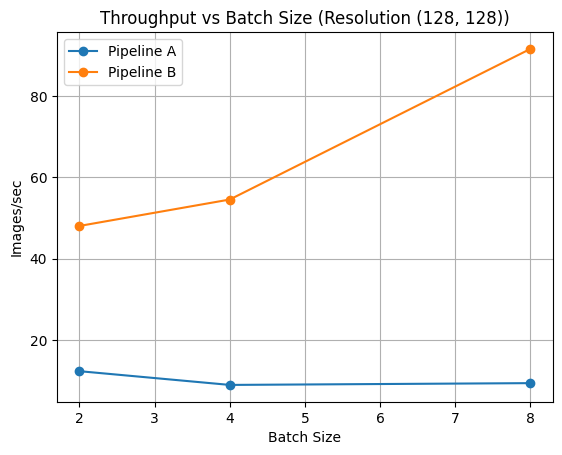

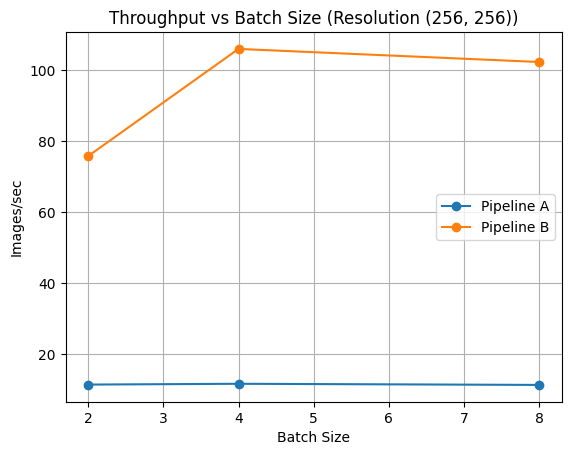

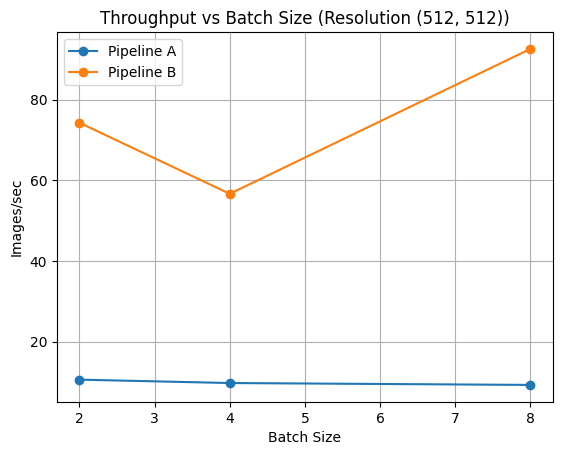

In [29]:
import matplotlib.pyplot as plt

for res in df["Resolution"].unique():
    subset = df[df["Resolution"] == res]

    plt.figure()

    plt.plot(subset["Batch Size"], subset["Throughput A"], marker='o', label="Pipeline A")
    plt.plot(subset["Batch Size"], subset["Throughput B"], marker='o', label="Pipeline B")

    plt.title(f"Throughput vs Batch Size (Resolution {res})")
    plt.xlabel("Batch Size")
    plt.ylabel("Images/sec")
    plt.legend()
    plt.grid()

    plt.show()